# PA-30 — Exécution du pipeline VAD + Diarisation sur le AMI Corpus
**Sprint 2 | Équipe P07 | Projet Stellantis**

Ce notebook fait tourner le pipeline Silero VAD + pyannote sur un échantillon aléatoire du AMI Corpus.  
Prérequis : avoir exécuté le notebook PA-28 au moins une fois (dépendances installées, token HuggingFace configuré).

## 1. Installation des dépendances
⚠️ Redémarrer le runtime après cette cellule.

In [ ]:
!pip install -q pyannote.audio silero-vad librosa soundfile
print('✅ Installation OK — redémarre le runtime !')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.7/893.7 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━

## 2. Chargement des modèles
Patch de compatibilité torchaudio + chargement de Silero VAD et du pipeline pyannote.

In [ ]:
import torchaudio, torch

# Patch compatibilité torchaudio / pyannote
if not hasattr(torchaudio, 'AudioMetaData'):
    try:
        from torchaudio._backend.utils import AudioMetaData
    except:
        import collections
        AudioMetaData = collections.namedtuple('AudioMetaData',
            ['sample_rate', 'num_frames', 'num_channels', 'bits_per_sample', 'encoding'])
    torchaudio.AudioMetaData = AudioMetaData

from pyannote.audio import Pipeline
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
pipeline = Pipeline.from_pretrained(
    'pyannote/speaker-diarization-3.1',
    token=HF_TOKEN
)
print('✅ pyannote chargé')

# Silero VAD
vad_model, utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad',
    model='silero_vad',
    force_reload=False,
    trust_repo=True
)
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils
print('✅ Silero VAD chargé')

config.yaml:   0%|          | 0.00/469 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

✅ pyannote chargé
Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip
✅ Silero VAD chargé


## 3. Upload des fichiers AMI Corpus
Uploader plusieurs fichiers audio AMI (wav ou flac). Le script en sélectionne un échantillon aléatoire de 3 fichiers.

In [ ]:
from google.colab import files
import os, random, librosa, soundfile as sf

uploaded = files.upload()
all_files = list(uploaded.keys())
print(f'📁 {len(all_files)} fichier(s) uploadé(s) : {all_files}')

# Échantillon aléatoire (max 3 fichiers)
N_SAMPLE = min(3, len(all_files))
sample_files = random.sample(all_files, N_SAMPLE)
print(f'\n🎲 Échantillon sélectionné ({N_SAMPLE} fichiers) :')
for f in sample_files:
    print(f'   - {f}')

# Conversion en wav 16kHz mono
converted_files = []
os.makedirs('ami_converted', exist_ok=True)
for fname in sample_files:
    audio, sr = librosa.load(fname, sr=16000, mono=True)
    out_path = f'ami_converted/{os.path.splitext(fname)[0]}.wav'
    sf.write(out_path, audio, 16000)
    converted_files.append(out_path)
    print(f'✅ Converti : {fname} → {out_path} ({len(audio)/16000:.1f}s)')

Saving ES2002a_5min.wav to ES2002a_5min.wav
Saving ES2002b_5min.wav to ES2002b_5min.wav
📁 2 fichier(s) uploadé(s) : ['ES2002a_5min.wav', 'ES2002b_5min.wav']

🎲 Échantillon sélectionné (2 fichiers) :
   - ES2002b_5min.wav
   - ES2002a_5min.wav
✅ Converti : ES2002b_5min.wav → ami_converted/ES2002b_5min.wav (300.0s)
✅ Converti : ES2002a_5min.wav → ami_converted/ES2002a_5min.wav (300.0s)


## 4. Exécution du pipeline sur l'échantillon
Pour chaque fichier : VAD → Diarisation → export JSON.

In [ ]:
import json, datetime

SAMPLE_RATE = 16000
all_results = {}

for audio_path in converted_files:
    print(f'\n{'='*55}')
    print(f'🎵 Traitement : {audio_path}')
    print('='*55)

    # Chargement
    waveform, sr = torchaudio.load(audio_path)
    audio_1d = waveform.squeeze(0)

    duration = audio_1d.shape[0] / SAMPLE_RATE

    # VAD
    speech_timestamps = get_speech_timestamps(
        audio_1d, vad_model,
        sampling_rate=SAMPLE_RATE,
        threshold=0.5,
        min_speech_duration_ms=300,
        min_silence_duration_ms=200
    )
    print(f'  VAD : {len(speech_timestamps)} segment(s) de parole détecté(s)')

    # Diarisation
    diarization = pipeline(audio_path)
    annotation = diarization.speaker_diarization

    segments = []
    for segment, track, speaker in annotation.itertracks(yield_label=True):
        seg = {'start': round(segment.start, 3), 'end': round(segment.end, 3), 'speaker': speaker}
        segments.append(seg)
        print(f'  [{seg["start"]:6.2f}s → {seg["end"]:6.2f}s]  {speaker}')

    # Export JSON
    speakers_detected = list(set(s['speaker'] for s in segments))
    result = {
        'metadata': {
            'audio_file': os.path.basename(audio_path),
            'duration_s': round(duration, 3),
            'processed_at': datetime.datetime.now().isoformat(),
            'vad_model': 'silero-vad',
            'diarization_model': 'pyannote/speaker-diarization-3.1',
            'num_speakers_detected': len(speakers_detected)
        },
        'speakers': speakers_detected,
        'segments': segments
    }
    all_results[audio_path] = result

    json_path = audio_path.replace('.wav', '_output.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(result, f, ensure_ascii=False, indent=2)
    print(f'  ✅ JSON sauvegardé → {json_path}')
    print(f'  Locuteurs détectés : {len(speakers_detected)} | Segments : {len(segments)}')

print(f'\n✅ Pipeline terminé sur {len(converted_files)} fichier(s)')


🎵 Traitement : ami_converted/ES2002b_5min.wav
  VAD : 56 segment(s) de parole détecté(s)


/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


  [  2.71s →   3.04s]  SPEAKER_01
  [  3.04s →   3.07s]  SPEAKER_00
  [  3.07s →   3.12s]  SPEAKER_01
  [  6.97s →   9.99s]  SPEAKER_00
  [ 14.59s →  15.47s]  SPEAKER_00
  [ 17.02s →  17.89s]  SPEAKER_00
  [ 17.70s →  21.87s]  SPEAKER_01
  [ 19.66s →  20.08s]  SPEAKER_00
  [ 23.35s →  32.40s]  SPEAKER_00
  [ 27.44s →  28.21s]  SPEAKER_01
  [ 32.01s →  33.87s]  SPEAKER_01
  [ 34.56s →  64.17s]  SPEAKER_00
  [ 36.38s →  36.84s]  SPEAKER_01
  [100.94s → 157.75s]  SPEAKER_00
  [116.81s → 117.01s]  SPEAKER_01
  [141.24s → 141.63s]  SPEAKER_01
  [157.93s → 162.96s]  SPEAKER_01
  [163.18s → 171.19s]  SPEAKER_00
  [172.36s → 173.96s]  SPEAKER_01
  [174.01s → 203.05s]  SPEAKER_00
  [203.41s → 203.93s]  SPEAKER_00
  [204.56s → 208.01s]  SPEAKER_00
  [210.18s → 210.78s]  SPEAKER_01
  [211.04s → 211.05s]  SPEAKER_01
  [211.05s → 211.83s]  SPEAKER_00
  [217.23s → 219.62s]  SPEAKER_01
  [219.86s → 222.21s]  SPEAKER_00
  [258.54s → 262.13s]  SPEAKER_01
  [262.29s → 262.37s]  SPEAKER_01
  [265.51s → 2

## 5. Visualisation des résultats
Timeline des locuteurs pour chaque fichier de l'échantillon.

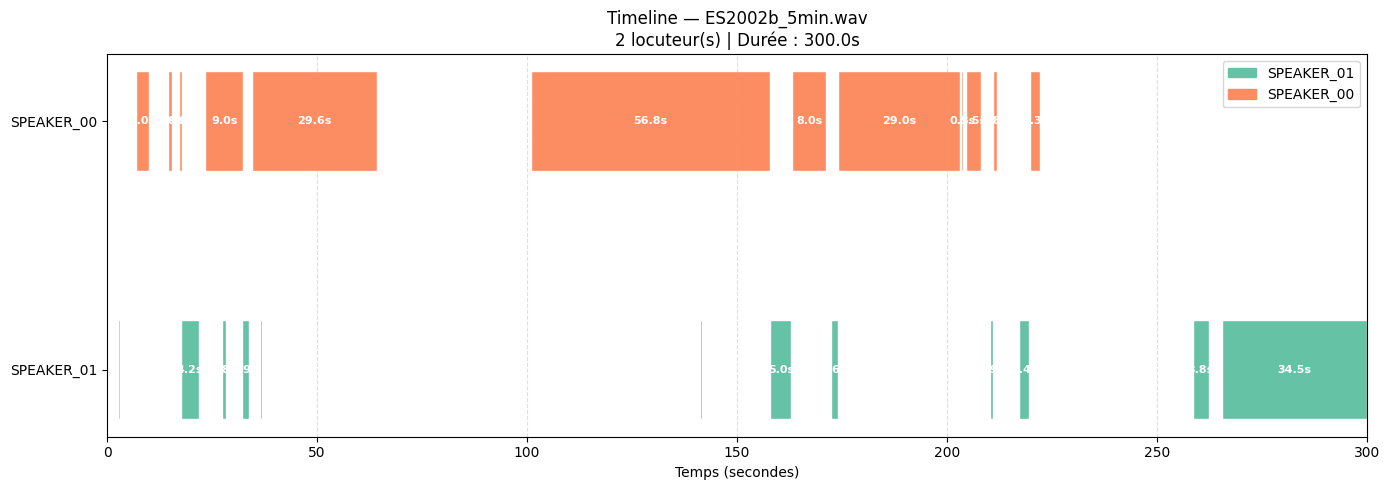

✅ Timeline sauvegardée → ami_converted/ES2002b_5min_timeline.png


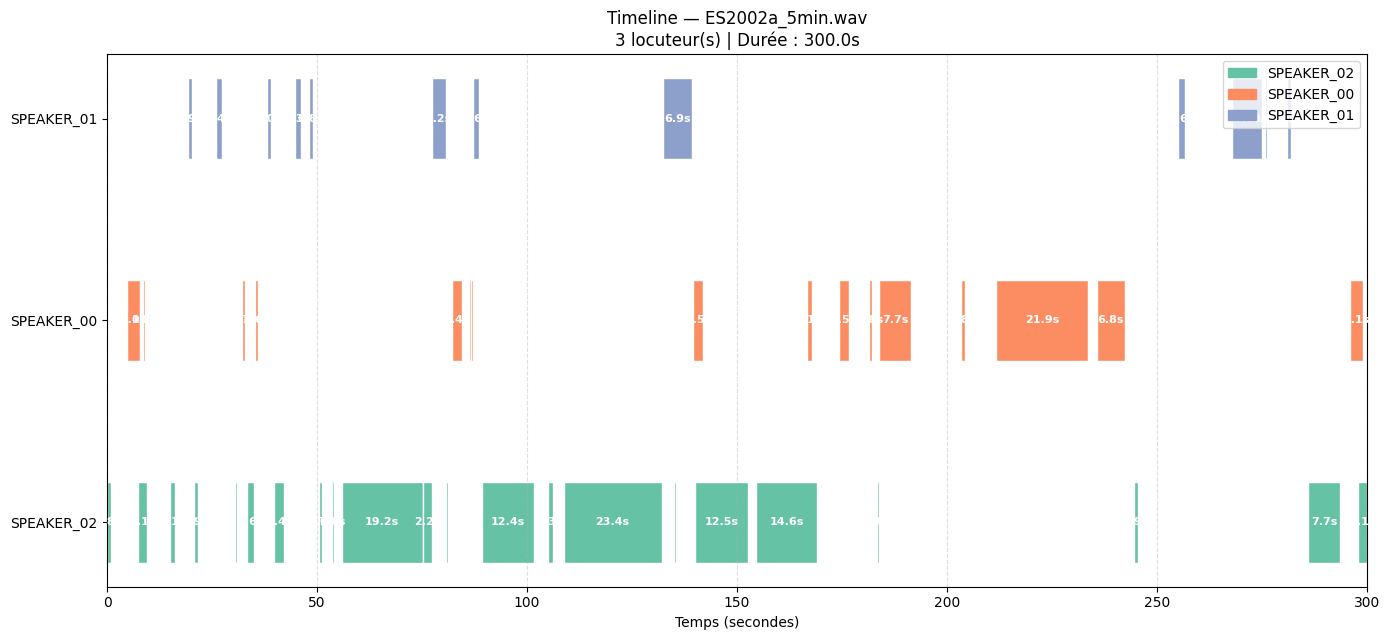

✅ Timeline sauvegardée → ami_converted/ES2002a_5min_timeline.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def merge_segments(segs, gap=0.3):
    merged = []
    for seg in sorted(segs, key=lambda x: x['start']):
        if merged and seg['speaker'] == merged[-1]['speaker'] and seg['start'] - merged[-1]['end'] < gap:
            merged[-1]['end'] = seg['end']
        else:
            merged.append(dict(seg))
    return merged

colors = plt.cm.Set2.colors

for audio_path, result in all_results.items():
    segments = result['segments']
    segments_merged = merge_segments(segments)
    speakers = list(dict.fromkeys(s['speaker'] for s in segments_merged))
    speaker_colors = {spk: colors[i % len(colors)] for i, spk in enumerate(speakers)}

    fig, ax = plt.subplots(figsize=(14, 2 + len(speakers) * 1.5))
    for seg in segments_merged:
        ax.barh(y=seg['speaker'], width=seg['end']-seg['start'],
                left=seg['start'], color=speaker_colors[seg['speaker']],
                edgecolor='white', height=0.4)
        duration = seg['end'] - seg['start']
        if duration > 0.5:
            ax.text(seg['start'] + duration/2, seg['speaker'],
                    f"{duration:.1f}s", ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')

    patches = [mpatches.Patch(color=speaker_colors[spk], label=spk) for spk in speakers]
    ax.legend(handles=patches, loc='upper right')
    ax.set_xlabel('Temps (secondes)')
    ax.set_title(f"Timeline — {result['metadata']['audio_file']}\n"
                 f"{result['metadata']['num_speakers_detected']} locuteur(s) | "
                 f"Durée : {result['metadata']['duration_s']}s")
    ax.set_xlim(0, result['metadata']['duration_s'])
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()

    img_path = audio_path.replace('.wav', '_timeline.png')
    plt.savefig(img_path, dpi=150)
    plt.show()
    print(f'✅ Timeline sauvegardée → {img_path}')

## 6. Récapitulatif
Synthèse des résultats sur l'ensemble de l'échantillon.

In [ ]:
print('=' * 60)
print('  RÉCAPITULATIF — PA-30 AMI Corpus')
print('=' * 60)
for audio_path, result in all_results.items():
    m = result['metadata']
    print(f"\n  📁 {m['audio_file']}")
    print(f"     Durée         : {m['duration_s']}s")
    print(f"     Locuteurs     : {m['num_speakers_detected']}")
    print(f"     Segments      : {len(result['segments'])}")
    print(f"     Traité le     : {m['processed_at']}")
print('\n' + '=' * 60)
print(f'  ✅ {len(all_results)} fichier(s) traité(s) avec succès')
print('  JSON et timelines sauvegardés dans ami_converted/')
print('=' * 60)

  RÉCAPITULATIF — PA-30 AMI Corpus

  📁 ES2002b_5min.wav
     Durée         : 300.0s
     Locuteurs     : 2
     Segments      : 31
     Traité le     : 2026-06-02T08:56:10.018839

  📁 ES2002a_5min.wav
     Durée         : 300.0s
     Locuteurs     : 3
     Segments      : 74
     Traité le     : 2026-06-02T09:13:46.267585

  ✅ 2 fichier(s) traité(s) avec succès
  JSON et timelines sauvegardés dans ami_converted/


## 7. Évaluation des performances — DER (PA-31)
Comparaison des sorties du pipeline aux annotations de référence AMI.
Le DER (Diarization Error Rate) mesure le % de temps mal attribué.
Un DER < 30% est acceptable pour un prototype sur micro unique.

In [ ]:
from google.colab import files
import zipfile, os

uploaded_zip = files.upload()
zip_name = list(uploaded_zip.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall("ami_annotations/")
print("✅ Annotations extraites")
print(os.listdir("ami_annotations/"))

Saving segments.zip to segments.zip
✅ Annotations extraites
['__MACOSX', 'segments']


In [ ]:
import os
import glob
import xml.etree.ElementTree as ET
import soundfile as sf

from pyannote.core import Segment, Annotation
from pyannote.metrics.diarization import DiarizationErrorRate


# Chargement des annotations AMI tronquées à la durée audio

def parse_ami_segments(annotations_folder, meeting_id, max_time):

    reference = Annotation()

    pattern = os.path.join(
        annotations_folder,
        f"**/{meeting_id}.*.segments.xml"
    )

    files = glob.glob(pattern, recursive=True)

    if not files:
        print(f"⚠️ Aucun fichier trouvé pour {meeting_id}")
        return None

    total_segments = 0

    for filepath in sorted(files):

        speaker = os.path.basename(filepath).split(".")[1]

        tree = ET.parse(filepath)
        root = tree.getroot()

        segments = root.findall(".//segment")

        print(f"📄 {os.path.basename(filepath)} -> {len(segments)} segments")

        for seg in segments:

            start = float(seg.get("transcriber_start"))
            end   = float(seg.get("transcriber_end"))

            # GARDE uniquement les segments dans la fenêtre audio


            if start >= max_time:
                continue

            end = min(end, max_time)

            if end <= start:
                continue

            reference[Segment(start, end)] = f"SPEAKER_{speaker}"

            total_segments += 1

    print(f"✅ Référence chargée : {total_segments} segments")

    return reference


# Conversion pipeline -> Annotation pyannote


def pipeline_to_annotation(segments):

    hypothesis = Annotation()

    for seg in segments:

        hypothesis[
            Segment(seg["start"], seg["end"])
        ] = seg["speaker"]

    return hypothesis



# CALCUL DER

der_metric = DiarizationErrorRate()

print("=" * 60)
print("           CALCUL DU DER — PA-31")
print("=" * 60)

for audio_path, result in all_results.items():

    meeting_id = os.path.basename(audio_path).split(".")[0]

    # Supprime "(1)"
    meeting_id = meeting_id.split(" (")[0]

    # Supprime "_5min"
    meeting_id = meeting_id.replace("_5min", "")

    print(f"\n📁 {meeting_id}")

    # =====================================================
    # Durée réelle audio
    # =====================================================

    audio, sr = sf.read(audio_path)

    max_time = len(audio) / sr

    print(f"⏱️ Durée audio : {max_time:.2f} sec")

    # =====================================================
    # Référence tronquée
    # =====================================================

    reference = parse_ami_segments(
        "ami_annotations/",
        meeting_id,
        max_time
    )

    if reference is None:
        print("⚠️ Référence manquante")
        continue

    # =====================================================
    # Nettoyage hypothèse
    # =====================================================

    clean_segments = []

    for seg in result["segments"]:

        start = max(0, seg["start"])
        end   = min(seg["end"], max_time)

        if end <= start:
            continue

        clean_segments.append({
            "start": start,
            "end": end,
            "speaker": seg["speaker"]
        })

    print(f"🧠 Segments prédits : {len(clean_segments)}")

    # =====================================================
    # Construction hypothèse
    # =====================================================

    hypothesis = pipeline_to_annotation(clean_segments)

    # =====================================================
    # DER
    # =====================================================

    der = der_metric(reference, hypothesis)

    print(f"\n🎯 DER : {der * 100:.1f}%")

    if der < 0.30:
        print("✅ Acceptable (<30%)")
    else:
        print("⚠️ À optimiser (>30%)")


# =========================================================
# DER global
# =========================================================

global_der = abs(der_metric)

print(f"\n{'='*60}")
print(f"DER MOYEN GLOBAL : {global_der * 100:.1f}%")
print(f"Seuil acceptable : < 30%")
print(f"{'='*60}")

           CALCUL DU DER — PA-31

📁 ES2002b
⏱️ Durée audio : 300.00 sec
📄 ES2002b.A.segments.xml -> 63 segments
📄 ES2002b.B.segments.xml -> 179 segments
📄 ES2002b.C.segments.xml -> 38 segments
📄 ES2002b.D.segments.xml -> 179 segments
✅ Référence chargée : 34 segments
🧠 Segments prédits : 31

🎯 DER : 19.2%
✅ Acceptable (<30%)

📁 ES2002a
⏱️ Durée audio : 300.00 sec
📄 ES2002a.A.segments.xml -> 34 segments
📄 ES2002a.B.segments.xml -> 109 segments
📄 ES2002a.C.segments.xml -> 19 segments
📄 ES2002a.D.segments.xml -> 115 segments
✅ Référence chargée : 55 segments
🧠 Segments prédits : 74

🎯 DER : 38.8%
⚠️ À optimiser (>30%)

DER MOYEN GLOBAL : 29.3%
Seuil acceptable : < 30%


/usr/local/lib/python3.12/dist-packages/pyannote/metrics/utils.py:200: UserWarning: 'uem' was approximated by the union of 'reference' and 'hypothesis' extents.
  warnings.warn(


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def annotation_to_segments(annotation):
    segs = []
    for segment, track, speaker in annotation.itertracks(yield_label=True):
        segs.append({
            "start": segment.start,
            "end": segment.end,
            "speaker": speaker
        })
    return segs

def plot_prediction_vs_reference(reference, hypothesis_segments, title, max_time):
    ref_segments = annotation_to_segments(reference)

    speakers = sorted(set(
        [s["speaker"] for s in ref_segments] +
        [s["speaker"] for s in hypothesis_segments]
    ))

    colors = plt.cm.Set2.colors
    speaker_colors = {
        spk: colors[i % len(colors)]
        for i, spk in enumerate(speakers)
    }

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

    timelines = [
        ("Vérité terrain", ref_segments),
        ("Prédiction modèle", hypothesis_segments)
    ]

    for ax, (name, segments) in zip(axes, timelines):
        for seg in segments:
            ax.barh(
                y=seg["speaker"],
                width=seg["end"] - seg["start"],
                left=seg["start"],
                color=speaker_colors[seg["speaker"]],
                edgecolor="white",
                height=0.45
            )

        ax.set_title(name)
        ax.set_xlim(0, max_time)
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        ax.set_ylabel("Locuteurs")

    axes[-1].set_xlabel("Temps (secondes)")

    patches = [
        mpatches.Patch(color=speaker_colors[spk], label=spk)
        for spk in speakers
    ]

    fig.legend(handles=patches, loc="upper right")
    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

📄 ES2002b.A.segments.xml -> 63 segments
📄 ES2002b.B.segments.xml -> 179 segments
📄 ES2002b.C.segments.xml -> 38 segments
📄 ES2002b.D.segments.xml -> 179 segments
✅ Référence chargée : 34 segments


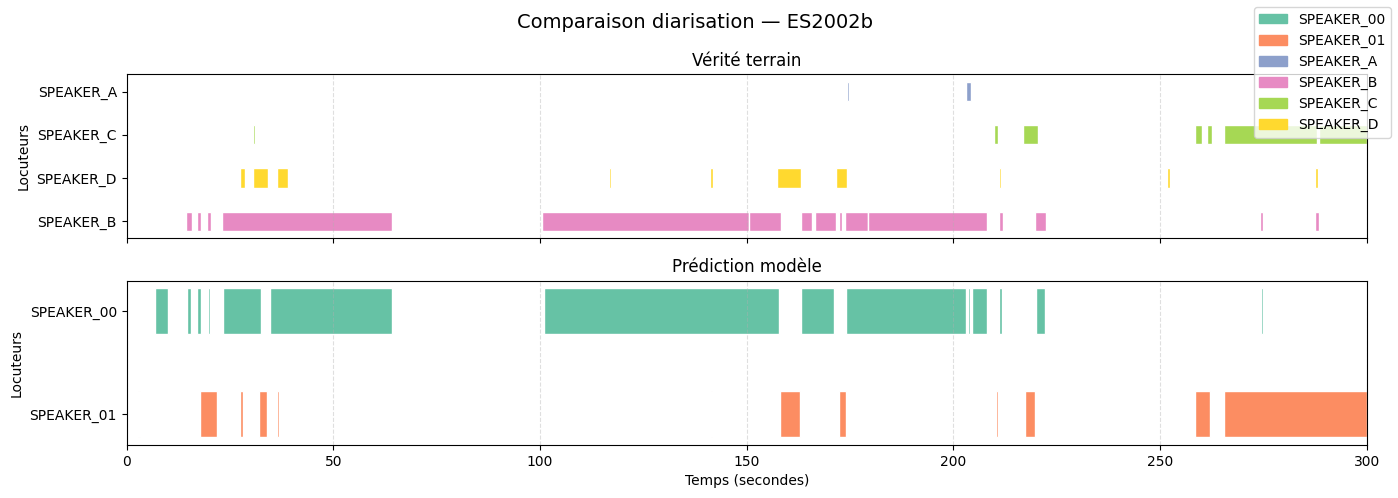

📄 ES2002a.A.segments.xml -> 34 segments
📄 ES2002a.B.segments.xml -> 109 segments
📄 ES2002a.C.segments.xml -> 19 segments
📄 ES2002a.D.segments.xml -> 115 segments
✅ Référence chargée : 55 segments


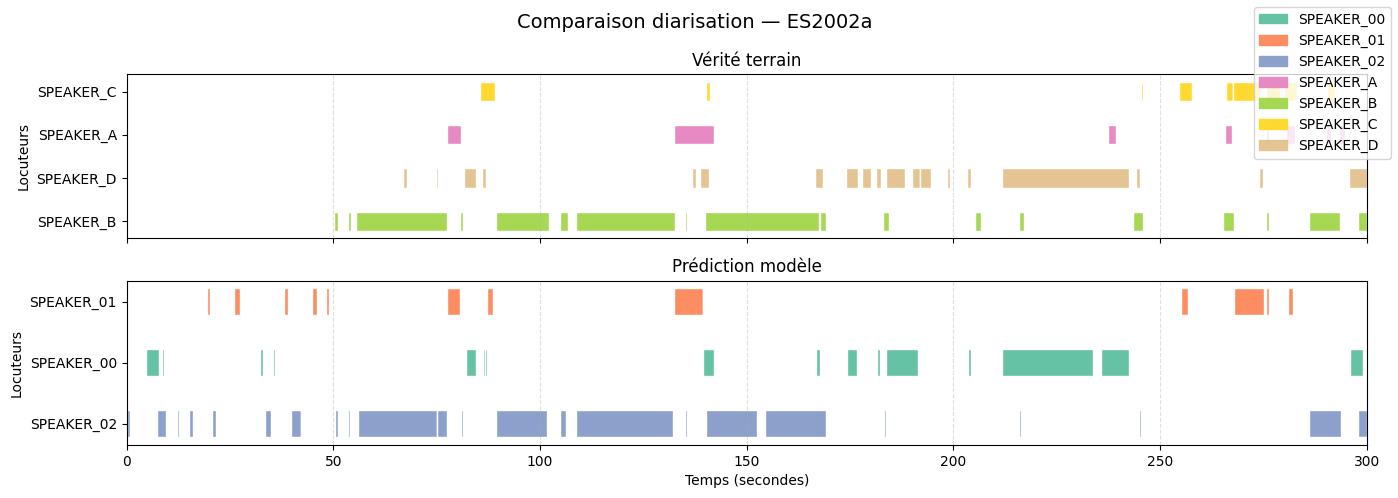

In [ ]:
for audio_path, result in all_results.items():

    meeting_id = os.path.basename(audio_path).split(".")[0]

    # Nettoyage nom
    meeting_id = meeting_id.split(" (")[0]
    meeting_id = meeting_id.replace("_5min", "")

    audio, sr = sf.read(audio_path)

    max_time = len(audio) / sr

    reference = parse_ami_segments(
        "ami_annotations/",
        meeting_id,
        max_time
    )

    if reference is None:
        continue

    clean_segments = []

    for seg in result["segments"]:

        start = max(0, seg["start"])
        end = min(seg["end"], max_time)

        if end <= start:
            continue

        clean_segments.append({
            "start": start,
            "end": end,
            "speaker": seg["speaker"]
        })

    plot_prediction_vs_reference(
        reference,
        clean_segments,
        title=f"Comparaison diarisation — {meeting_id}",
        max_time=max_time
    )